In [4]:
# Импорты и настройки
import os
import sys
import random
import subprocess
import re
import warnings
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

# Фиксируем seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Установка необходимых пакетов (если их нет)
def ensure_package(pkg, import_name=None):
    target = import_name or pkg
    try:
        __import__(target)
    except ImportError:
        print(f"Устанавливаем {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

ensure_package("faiss-cpu", "faiss")
ensure_package("sentence-transformers")

import faiss
from sentence_transformers import SentenceTransformer

# Устройство
try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except:
    DEVICE = "cpu"
print(f"Устройство: {DEVICE}")

if DEVICE == "cuda":
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("NumPy:", np.__version__)
print("FAISS доступен")
print("sentence-transformers доступен")

Устанавливаем sentence-transformers...
Устройство: cpu
NumPy: 2.3.2
FAISS доступен
sentence-transformers доступен


In [5]:
# База знаний (10 документов по ML)
documents = [
    {
        "doc_id": "doc_01",
        "title": "Линейная регрессия",
        "text": "Линейная регрессия – это базовый метод машинного обучения для предсказания непрерывной целевой переменной. Модель предполагает линейную связь между признаками и откликом. Обучение происходит методом наименьших квадратов."
    },
    {
        "doc_id": "doc_02",
        "title": "Логистическая регрессия",
        "text": "Логистическая регрессия используется для бинарной классификации. Она оценивает вероятность принадлежности образца к классу с помощью сигмоидной функции. Обучение основано на максимизации правдоподобия."
    },
    {
        "doc_id": "doc_03",
        "title": "Деревья решений",
        "text": "Деревья решений – это нелинейный метод, который разделяет пространство признаков на области. Каждый внутренний узел соответствует проверке признака, листья – предсказанию. Они легко интерпретируемы, но склонны к переобучению."
    },
    {
        "doc_id": "doc_04",
        "title": "Случайный лес",
        "text": "Случайный лес – ансамбль деревьев решений, построенных на случайных подвыборках данных и признаков. Он уменьшает переобучение и даёт высокую точность. Применяется для классификации и регрессии."
    },
    {
        "doc_id": "doc_05",
        "title": "Градиентный бустинг",
        "text": "Градиентный бустинг последовательно обучает слабые модели, корректируя ошибки предыдущих. Популярные реализации: XGBoost, LightGBM, CatBoost. Один из самых мощных методов для табличных данных."
    },
    {
        "doc_id": "doc_06",
        "title": "Метод опорных векторов (SVM)",
        "text": "SVM строит гиперплоскость, максимизирующую отступ между классами. Ядерный трюк позволяет работать с нелинейными данными. Эффективен на размерностях выше числа образцов."
    },
    {
        "doc_id": "doc_07",
        "title": "K-ближайших соседей (KNN)",
        "text": "KNN – ленивый алгоритм, предсказывающий по k ближайшим соседям. Не требует обучения, но медленный на больших данных. Чувствителен к масштабу признаков."
    },
    {
        "doc_id": "doc_08",
        "title": "Кластеризация K-means",
        "text": "K-means разбивает данные на K кластеров, минимизируя внутрикластерное расстояние. Итеративно обновляет центроиды. Чувствителен к начальным центрам и выбросам."
    },
    {
        "doc_id": "doc_09",
        "title": "Нейронные сети",
        "text": "Нейронные сети состоят из слоёв нейронов с нелинейными активациями. Глубокое обучение позволяет извлекать иерархические признаки. Обучение происходит через обратное распространение ошибки."
    },
    {
        "doc_id": "doc_10",
        "title": "Регуляризация",
        "text": "Регуляризация (L1, L2) предотвращает переобучение, добавляя штраф за большие веса. L1 порождает разреженные веса, L2 – сглаживание. Dropout – популярная техника для нейронных сетей."
    }
]

print(f"Всего документов: {len(documents)}")
df_docs = pd.DataFrame(documents)
display(df_docs[["doc_id", "title"]].head())

Всего документов: 10


,doc_id,title
0,doc_01,Линейная регрессия
1,doc_02,Логистическая регрессия
2,doc_03,Деревья решений
3,doc_04,Случайный лес
4,doc_05,Градиентный бустинг


In [6]:
# Чанкинг документов
def chunk_text(text: str, chunk_size: int = 30, overlap: int = 10) -> List[str]:
    words = text.split()
    if chunk_size <= 0 or overlap >= chunk_size:
        raise ValueError("Некорректные параметры чанкинга")
    step = chunk_size - overlap
    chunks = []
    for start in range(0, len(words), step):
        chunk = " ".join(words[start:start+chunk_size])
        if chunk:
            chunks.append(chunk)
        if start + chunk_size >= len(words):
            break
    return chunks

CHUNK_SIZE = 30
OVERLAP = 10

chunks_list = []
for doc in documents:
    chunks = chunk_text(doc["text"], chunk_size=CHUNK_SIZE, overlap=OVERLAP)
    for i, chunk in enumerate(chunks):
        chunks_list.append({
            "doc_id": doc["doc_id"],
            "title": doc["title"],
            "chunk_id": f"{doc['doc_id']}_chunk_{i:02d}",
            "chunk_text": chunk,
            "word_count": len(chunk.split())
        })

chunks_df = pd.DataFrame(chunks_list)
print(f"Всего чанков: {len(chunks_df)}")
print("\nПримеры чанков:")
display(chunks_df.head())

Всего чанков: 10

Примеры чанков:


,doc_id,title,chunk_id,chunk_text,word_count
0,doc_01,Линейная регрессия,doc_01_chunk_00,Линейная регрессия – это базовый метод машинно...,26
1,doc_02,Логистическая регрессия,doc_02_chunk_00,Логистическая регрессия используется для бинар...,22
2,doc_03,Деревья решений,doc_03_chunk_00,"Деревья решений – это нелинейный метод, которы...",28
3,doc_04,Случайный лес,doc_04_chunk_00,"Случайный лес – ансамбль деревьев решений, пос...",25
4,doc_05,Градиентный бустинг,doc_05_chunk_00,Градиентный бустинг последовательно обучает сл...,22


In [7]:
# Эмбеддинги и индекс FAISS
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', device=DEVICE)

chunk_texts = chunks_df["chunk_text"].tolist()
chunk_embeddings = model.encode(chunk_texts, convert_to_numpy=True, normalize_embeddings=True).astype('float32')
print(f"Размерность эмбеддингов: {chunk_embeddings.shape[1]}")

dim = chunk_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(chunk_embeddings)
print("Индекс FAISS построен.")

def search(query: str, top_k: int = 3, idx=index, df=chunks_df) -> pd.DataFrame:
    query_emb = model.encode([query], convert_to_numpy=True, normalize_embeddings=True).astype('float32')
    scores, indices = idx.search(query_emb, top_k)
    results = df.iloc[indices[0]].copy()
    results["score"] = scores[0]
    results.insert(0, "rank", range(1, len(results)+1))
    return results[["rank", "score", "doc_id", "title", "chunk_id", "chunk_text"]]

# Тестовые запросы
test_queries = [
    "Как работает логистическая регрессия?",
    "Что такое случайный лес?",
    "Как бороться с переобучением?"
]
for q in test_queries:
    print(f"\nЗапрос: {q}")
    display(search(q, top_k=2))

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

,rank,score,doc_id,title,chunk_id,chunk_text
1,1,0.591251,doc_02,Логистическая регрессия,doc_02_chunk_00,Логистическая регрессия используется для бинар...
2,2,0.580541,doc_03,Деревья решений,doc_03_chunk_00,"Деревья решений – это нелинейный метод, которы..."



Запрос: Что такое случайный лес?


,rank,score,doc_id,title,chunk_id,chunk_text
3,1,0.719434,doc_04,Случайный лес,doc_04_chunk_00,"Случайный лес – ансамбль деревьев решений, пос..."
2,2,0.518290,doc_03,Деревья решений,doc_03_chunk_00,"Деревья решений – это нелинейный метод, которы..."



Запрос: Как бороться с переобучением?


,rank,score,doc_id,title,chunk_id,chunk_text
9,1,0.342796,doc_10,Регуляризация,doc_10_chunk_00,"Регуляризация (L1, L2) предотвращает переобуче..."
8,2,0.309127,doc_09,Нейронные сети,doc_09_chunk_00,Нейронные сети состоят из слоёв нейронов с нел...


In [9]:
# Контрольные запросы и оценка retrieval (hit@k, recall@k, MRR)
control_queries = [
    {"query": "Как предсказывать непрерывную переменную?", "expected_doc_id": "doc_01"},
    {"query": "Что такое сигмоида?", "expected_doc_id": "doc_02"},
    {"query": "Нелинейный метод, похожий на блок-схему", "expected_doc_id": "doc_03"},
    {"query": "Ансамбль деревьев", "expected_doc_id": "doc_04"},
    {"query": "XGBoost и LightGBM", "expected_doc_id": "doc_05"},
    {"query": "Гиперплоскость и ядерный трюк", "expected_doc_id": "doc_06"},
    {"query": "Ленивый алгоритм, основанный на расстоянии", "expected_doc_id": "doc_07"},
    {"query": "Разбиение данных на K центров", "expected_doc_id": "doc_08"},
    {"query": "Глубокое обучение и обратное распространение", "expected_doc_id": "doc_09"},
    {"query": "Штраф за большие веса", "expected_doc_id": "doc_10"},
]

TOP_K = 3

results_eval = []
for item in control_queries:
    query = item["query"]
    expected = item["expected_doc_id"]
    retrieved = search(query, top_k=TOP_K)
    retrieved_ids = retrieved["doc_id"].tolist()
    hit = int(expected in retrieved_ids)
    rank = retrieved[retrieved["doc_id"] == expected]["rank"].values
    rank_of_first = int(rank[0]) if len(rank) > 0 else None
    results_eval.append({
        "query": query,
        "expected_source": expected,
        "retrieved_sources": ", ".join(retrieved_ids),
        "hit_at_k": hit,
        "rank_of_first_relevant": rank_of_first
    })

eval_df = pd.DataFrame(results_eval)
print(f"hit@{TOP_K} = {eval_df['hit_at_k'].mean():.2f}")
print(f"recall@{TOP_K} = {eval_df['hit_at_k'].mean():.2f}")  # recall = hit для одного релевантного документа
mrr = eval_df['rank_of_first_relevant'].apply(lambda x: 1/x if x is not None else 0).mean()
print(f"MRR@{TOP_K} = {mrr:.2f}")

display(eval_df)

os.makedirs("artifacts", exist_ok=True)
eval_df.to_csv("artifacts/retrieval_eval.csv", index=False)
print("Сохранено: artifacts/retrieval_eval.csv")

hit@3 = 0.90
recall@3 = 0.90
MRR@3 = 1.00


,query,expected_source,retrieved_sources,hit_at_k,rank_of_first_relevant
0,Как предсказывать непрерывную переменную?,doc_01,"doc_01, doc_02, doc_03",1,1.0
1,Что такое сигмоида?,doc_02,"doc_04, doc_05, doc_06",0,NaN
2,"Нелинейный метод, похожий на блок-схему",doc_03,"doc_03, doc_07, doc_05",1,1.0
3,Ансамбль деревьев,doc_04,"doc_04, doc_03, doc_08",1,1.0
4,XGBoost и LightGBM,doc_05,"doc_05, doc_08, doc_06",1,1.0
5,Гиперплоскость и ядерный трюк,doc_06,"doc_06, doc_05, doc_08",1,1.0
6,"Ленивый алгоритм, основанный на расстоянии",doc_07,"doc_07, doc_03, doc_06",1,1.0
7,Разбиение данных на K центров,doc_08,"doc_08, doc_07, doc_05",1,1.0
8,Глубокое обучение и обратное распространение,doc_09,"doc_09, doc_07, doc_05",1,1.0
9,Штраф за большие веса,doc_10,"doc_10, doc_06, doc_05",1,1.0


Сохранено: artifacts/retrieval_eval.csv


In [10]:
# Эксперимент с параметрами – сравнение top_k=1 и top_k=3
def evaluate_top_k(k: int) -> float:
    hits = 0
    for item in control_queries:
        retrieved = search(item["query"], top_k=k)
        if item["expected_doc_id"] in retrieved["doc_id"].tolist():
            hits += 1
    return hits / len(control_queries)

hit_k1 = evaluate_top_k(1)
hit_k3 = evaluate_top_k(3)
print(f"hit@1 = {hit_k1:.2f}")
print(f"hit@3 = {hit_k3:.2f}")
print("Вывод: увеличение top_k с 1 до 3 повышает recall, но может добавлять шум. Для mini-RAG используем top_k=3.")

hit@1 = 0.90
hit@3 = 0.90
Вывод: увеличение top_k с 1 до 3 повышает recall, но может добавлять шум. Для mini-RAG используем top_k=3.


In [11]:
# Обновление базы знаний (добавляем 3 новых документа)
new_docs = [
    {
        "doc_id": "doc_11",
        "title": "Автокодировщики",
        "text": "Автокодировщики – нейронные сети для неконтролируемого обучения. Они сжимают входные данные в скрытое представление и восстанавливают их. Применяются для уменьшения размерности и шумоподавления."
    },
    {
        "doc_id": "doc_12",
        "title": "Обучение с подкреплением",
        "text": "Обучение с подкреплением – агент учится на основе наград. Популярные методы: Q-learning, policy gradients. Применяется в играх, робототехнике."
    },
    {
        "doc_id": "doc_13",
        "title": "Градиентный спуск",
        "text": "Градиентный спуск – оптимизационный алгоритм для минимизации функции потерь. Варианты: стохастический, мини-батч, Adam. Основа обучения нейронных сетей."
    }
]

documents_updated = documents + new_docs
print(f"Было документов: {len(documents)}, стало: {len(documents_updated)}")

# Переиндексация
chunks_updated = []
for doc in documents_updated:
    chunks = chunk_text(doc["text"], chunk_size=CHUNK_SIZE, overlap=OVERLAP)
    for i, ch in enumerate(chunks):
        chunks_updated.append({
            "doc_id": doc["doc_id"],
            "title": doc["title"],
            "chunk_id": f"{doc['doc_id']}_chunk_{i:02d}",
            "chunk_text": ch,
        })
chunks_df_updated = pd.DataFrame(chunks_updated)
emb_updated = model.encode(chunks_df_updated["chunk_text"].tolist(), convert_to_numpy=True, normalize_embeddings=True).astype('float32')
index_updated = faiss.IndexFlatIP(dim)
index_updated.add(emb_updated)

def search_updated(query, top_k=3):
    q_emb = model.encode([query], convert_to_numpy=True, normalize_embeddings=True).astype('float32')
    scores, indices = index_updated.search(q_emb, top_k)
    results = chunks_df_updated.iloc[indices[0]].copy()
    results["score"] = scores[0]
    results.insert(0, "rank", range(1, len(results)+1))
    return results

# Сравнение до/после на запросах по новым темам
compare_queries = [
    "Что такое автокодировщики?",
    "Как работает обучение с подкреплением?",
    "Для чего нужен градиентный спуск?"
]

before_after = []
for q in compare_queries:
    old_res = search(q, top_k=3)
    old_sources = ", ".join(old_res["doc_id"].tolist())
    new_res = search_updated(q, top_k=3)
    new_sources = ", ".join(new_res["doc_id"].tolist())
    changed = old_sources != new_sources
    before_after.append({
        "query": q,
        "before_retrieved_sources": old_sources,
        "after_retrieved_sources": new_sources,
        "changed": changed
    })

comp_df = pd.DataFrame(before_after)
display(comp_df)
comp_df.to_csv("artifacts/retrieval_before_after_update.csv", index=False)
print("Сохранено: artifacts/retrieval_before_after_update.csv")

Было документов: 10, стало: 13


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Что такое автокодировщики?,"doc_04, doc_07, doc_03","doc_11, doc_04, doc_07",True
1,Как работает обучение с подкреплением?,"doc_09, doc_01, doc_05","doc_12, doc_09, doc_13",True
2,Для чего нужен градиентный спуск?,"doc_10, doc_03, doc_06","doc_13, doc_10, doc_03",True


Сохранено: artifacts/retrieval_before_after_update.csv


In [12]:
# Mini-RAG (извлечение контекста и генерация ответа)
def split_sentences(text: str) -> List[str]:
    return re.split(r'(?<=[.!?])\s+', text)

def generate_answer(query: str, top_k: int = 3) -> Dict:
    # 1. Retrieval (используем обновлённый индекс)
    retrieved = search_updated(query, top_k=top_k)
    # 2. Сбор контекста
    context_lines = []
    for _, row in retrieved.iterrows():
        context_lines.append(f"[{row['doc_id']}] {row['chunk_text']}")
    context = "\n\n".join(context_lines)
    # 3. Извлечение ответа: выбираем предложение из контекста, наиболее похожее на запрос (TF-IDF)
    sentences = []
    for _, row in retrieved.iterrows():
        sentences.extend(split_sentences(row["chunk_text"]))
    if not sentences:
        answer = "Не удалось найти ответ."
    else:
        vectorizer = TfidfVectorizer(ngram_range=(1,2)).fit([query] + sentences)
        query_vec = vectorizer.transform([query]).toarray()
        sent_vecs = vectorizer.transform(sentences).toarray()
        sim = cosine_similarity(query_vec, sent_vecs)[0]
        best_idx = np.argmax(sim)
        answer = sentences[best_idx] if sim[best_idx] > 0.1 else "Не найдено релевантного предложения."
    return {
        "question": query,
        "answer": answer,
        "retrieved_sources": ", ".join(retrieved["doc_id"].tolist())
    }

# Примеры работы mini-RAG
example_questions = [
    "Как работает градиентный бустинг?",
    "Чем отличается L1 от L2 регуляризации?",
    "Что такое автокодировщики?",
    "Как обучают нейронные сети?"
]

rag_examples = []
for q in example_questions:
    rag_examples.append(generate_answer(q, top_k=3))

rag_df = pd.DataFrame(rag_examples)
display(rag_df)
rag_df.to_csv("artifacts/rag_examples.csv", index=False)
print("Сохранено: artifacts/rag_examples.csv")

,question,answer,retrieved_sources
0,Как работает градиентный бустинг?,Не найдено релевантного предложения.,"doc_13, doc_12, doc_03"
1,Чем отличается L1 от L2 регуляризации?,"L1 порождает разреженные веса, L2 – сглаживание.","doc_10, doc_08, doc_01"
2,Что такое автокодировщики?,Автокодировщики – нейронные сети для неконтрол...,"doc_11, doc_04, doc_07"
3,Как обучают нейронные сети?,Автокодировщики – нейронные сети для неконтрол...,"doc_09, doc_11, doc_13"


Сохранено: artifacts/rag_examples.csv


In [13]:
# Анализ ошибок (пограничные случаи)
problem_queries = [
    "Как бороться с переобучением в нейронных сетях?",
    "Разница между случайным лесом и градиентным бустингом"
]

for q in problem_queries:
    print(f"\n--- Запрос: {q} ---")
    res = generate_answer(q, top_k=3)
    print(f"Ответ: {res['answer']}")
    print(f"Источники: {res['retrieved_sources']}")
    print("Проблема: в текущем корпусе нет явного сравнения методов; extractive-генератор не может синтезировать ответ.")


--- Запрос: Как бороться с переобучением в нейронных сетях? ---
Ответ: Не найдено релевантного предложения.
Источники: doc_09, doc_11, doc_13
Проблема: в текущем корпусе нет явного сравнения методов; extractive-генератор не может синтезировать ответ.

--- Запрос: Разница между случайным лесом и градиентным бустингом ---
Ответ: Не найдено релевантного предложения.
Источники: doc_04, doc_03, doc_13
Проблема: в текущем корпусе нет явного сравнения методов; extractive-генератор не может синтезировать ответ.


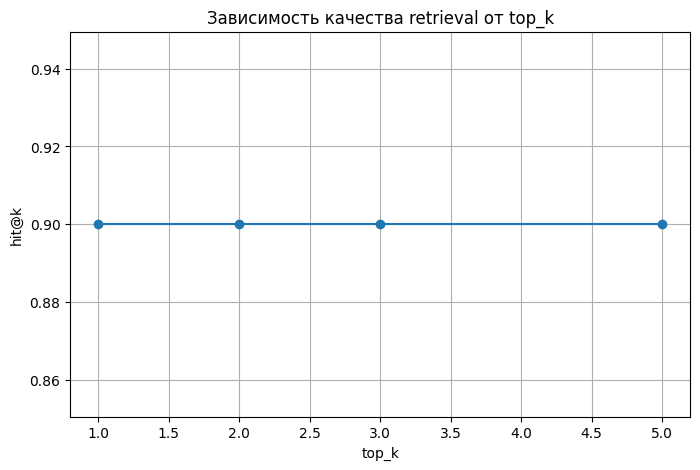

График сохранён в artifacts/hit_at_k_plot.png


In [14]:
# Дополнительная визуализация (опционально)
k_values = [1, 2, 3, 5]
hits = []
for k in k_values:
    hits_k = 0
    for item in control_queries:
        retrieved = search(item["query"], top_k=k)
        if item["expected_doc_id"] in retrieved["doc_id"].tolist():
            hits_k += 1
    hits.append(hits_k / len(control_queries))

plt.figure(figsize=(8,5))
plt.plot(k_values, hits, marker='o')
plt.xlabel("top_k")
plt.ylabel("hit@k")
plt.title("Зависимость качества retrieval от top_k")
plt.grid(True)
plt.savefig("artifacts/hit_at_k_plot.png")
plt.show()
print("График сохранён в artifacts/hit_at_k_plot.png")